https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

https://www.kaggle.com/code/geekysaint/solving-mnist-using-pytorch

In [104]:
import math

from torch import nn
from torch.nn.modules.module import register_module_forward_hook
from torchvision.datasets import MNIST, FashionMNIST
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import torch
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import trange
from IPython.display import display, clear_output

## Solution 1

In [2]:
labels = ["T-Shirt","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle Boot"]
root = '~/DataScience/datasets/'
train_data = MNIST(root, download=True, transform=ToTensor(), train=True)
test_data = MNIST(root, download=True, transform=ToTensor(), train=False)

In [3]:
is_first_training_batch = False

@register_module_forward_hook
def forward_hook(layer, x: list[torch.Tensor], y: torch.Tensor) -> None:
    """This runs after inference of each layer in model's forward pass."""
    if is_first_training_batch and isinstance(layer, nn.ReLU):
        layer.output_means.append(y.mean().item())
        layer.output_variances.append(y.var().item())

In [4]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item()/ len(preds))

def relu():
    activation = nn.ReLU()
    activation.output_means = []
    activation.output_variances = []
    return activation

class MnistModule(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.hidden_layers = nn.ModuleList([
            nn.Linear(784, 256),
            relu(),
            nn.Linear(256, 128),
            relu(),
            nn.Linear(128, 64),
            relu()
        ])
        self.output_layer = nn.Linear(64, 10)
        self.is_first_training_batch = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.flatten(x, start_dim=1)
        for layer in self.hidden_layers:
            x = layer(x)
        return self.output_layer(x)
    
    def validation_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = nn.functional.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        return {'val_loss':loss, 'val_acc': acc, 'out': out}
    
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc' : epoch_acc.item()}
    
model = MnistModule()

In [5]:
batch_size = 128
train_loader = DataLoader(train_data, batch_size, shuffle = True)
val_loader = DataLoader(test_data, batch_size, shuffle = False)

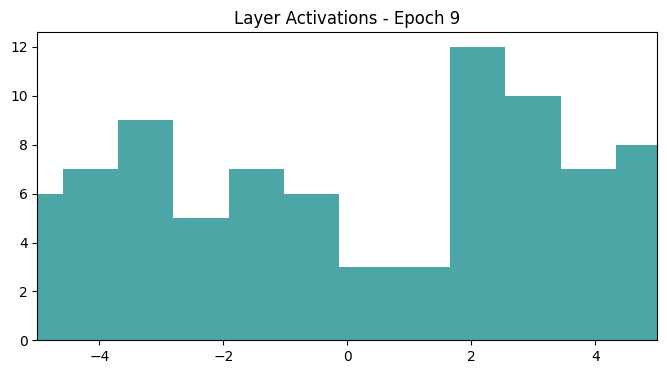

[{'val_loss': 0.3353109359741211, 'val_acc': 0.9010087251663208},
 {'val_loss': 0.20547060668468475, 'val_acc': 0.9385878443717957},
 {'val_loss': 0.14262232184410095, 'val_acc': 0.9572784900665283},
 {'val_loss': 0.12168817967176437, 'val_acc': 0.9634097814559937},
 {'val_loss': 0.09783388674259186, 'val_acc': 0.9709256291389465},
 {'val_loss': 0.08755912631750107, 'val_acc': 0.9730023741722107},
 {'val_loss': 0.08121342957019806, 'val_acc': 0.9755735993385315},
 {'val_loss': 0.08838088065385818, 'val_acc': 0.9730023741722107},
 {'val_loss': 0.07437972724437714, 'val_acc': 0.9778481125831604},
 {'val_loss': 0.08031757920980453, 'val_acc': 0.9766613841056824}]

In [6]:
def evaluate(model, val_loader) -> tuple[torch.Tensor, dict[str, float]]:
    outputs = [model.validation_step(batch) for batch in val_loader]
    metrics = model.validation_epoch_end(outputs)
    return outputs[-1]['out'], metrics

def fit(model, train_loader, val_loader, epochs: int, lr: float):
    global is_first_training_batch

    fig, ax = plt.subplots(figsize=(8, 4))
    history = []
    optimizer = torch.optim.SGD(model.parameters(), lr)
    for epoch in range(epochs):
        #print('Epoch', epoch)
        is_first_training_batch = True
        for batch in train_loader:
            images, labels = batch
            out = model(images)
            loss = nn.functional.cross_entropy(out, labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            is_first_training_batch = False

        out, metrics = evaluate(model, val_loader)
        history.append(metrics)
        #print("Epoch [{}], val_loss: {:.4f}, val_acc: {:.4f}".format(epoch, metrics['val_loss'], metrics['val_acc']))

        out = out.flatten().detach().cpu().numpy()
        ax.clear()
        ax.hist(out, bins=50, color='teal', alpha=0.7)
        ax.set_title(f"Layer Activations - Epoch {epoch}")
        ax.set_xlim(-5, 5)
        
        clear_output(wait=True)
        display(fig)            

    plt.close()
    return history

history = fit(model, train_loader, val_loader, epochs=10, lr=0.1)
history

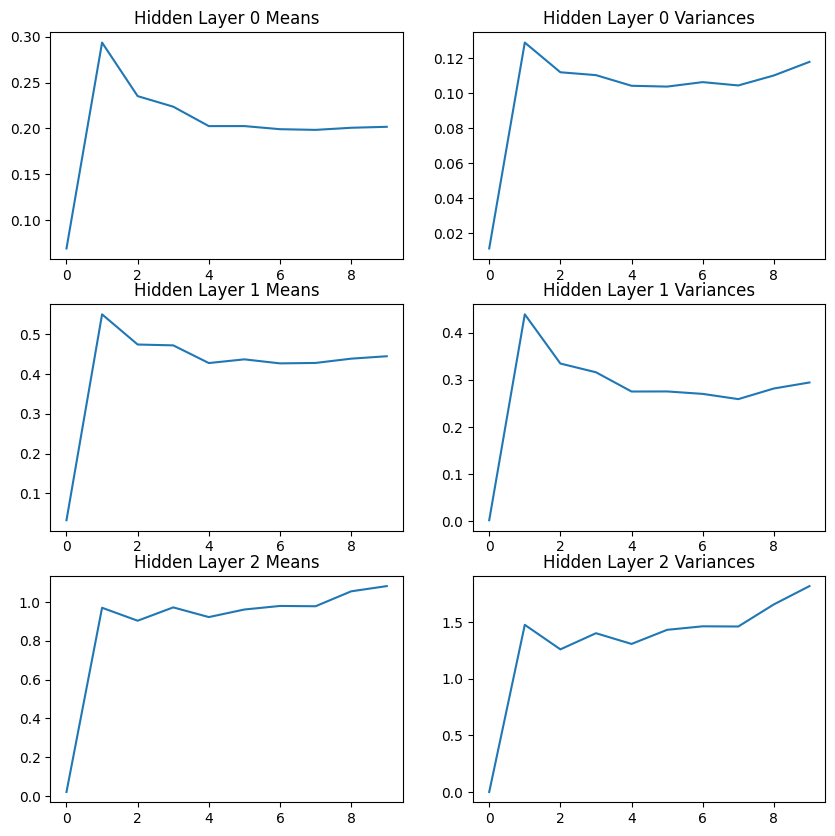

In [16]:
fig, axes = plt.subplots(3,2, figsize=(10,10))
for i in range(3):
    relu = model.hidden_layers[2*i + 1]
    axes[i,0].plot(np.arange(10), relu.output_means)
    axes[i,0].set_title(f'Hidden Layer {i} Means')

    axes[i,1].plot(np.arange(10), relu.output_variances)
    axes[i,1].set_title(f'Hidden Layer {i} Variances')

## Solution 4

In [102]:
f = lambda x: x[0]**2 + 100 * (x[1] - x[0]**2)**2    # rosenbrock function
fgrad = lambda x: np.array([2*x[0] + 400 * x[0]**3 - 400*x[0]*x[1], 200*x[1] - 200 * x[0]**2])    # (df/dx, df/dy)
max_epochs = 5000  
epsilon = 1e-6

def sgd(gradient, epoch):
    return gradient

class Adam:
    def __init__(self) -> None:
        self.m = 0
        self.v = 0
        self.beta_1 = 0.9
        self.beta_2 = 0.99

    def __call__(self, gradient, epoch: int):
        # first moment
        self.m = self.beta_1 * self.m + (1 - self.beta_1) * gradient
        k = self.m / (1 - self.beta_1 ** epoch)
        # second moment
        self.v = self.beta_2 * self.v + (1 - self.beta_2) * gradient**2
        s = self.v / (1 - self.beta_2 ** epoch)
        return k / (np.sqrt(s) + epsilon)

def fit(lr: float, x: np.ndarray, optimizer):
    losses = []
    history = []
    print('Starting point & loss:', x, f(x))
    for epoch in range(1, max_epochs+1):
        history.append(x)
        losses.append(f(x))
        x -= lr * optimizer(fgrad(x), epoch)
    return np.array(history), losses
    
def contour2d(ax, history, name: str):
    x_min, x_max = -2.0, 2.0
    y_min, y_max = -1.0, 3.0
    
    X, Y = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = (1 - X)**2 + 100 * (Y - X**2)**2  # Standard Rosenbrock
    
    # 2. Use Log-spaced contours for better visibility in the valley
    levels = np.logspace(-0.5, 3.5, 20) 
    cp = ax.contour(X, Y, Z, levels=levels, cmap='viridis', alpha=0.4, linewidths=0.8)
    ax.clabel(cp, inline=1, fontsize=6)
    
    # 3. Clean the history: Remove points outside our plot range 
    # This prevents the plot from "zooming out" to infinity if the model diverged
    mask = (history[:, 0] >= x_min) & (history[:, 0] <= x_max) & \
           (history[:, 1] >= y_min) & (history[:, 1] <= y_max)
    filtered_history = history[mask]

    ax.plot(filtered_history[:, 0], filtered_history[:, 1], color='red', lw=1.5, label='Path', zorder=3)
    
    # Plot every Nth point to show progress without clutter
    step = max(1, len(filtered_history) // 50)
    ax.scatter(filtered_history[::step, 0], filtered_history[::step, 1], 
               color='red', s=10, alpha=0.5, edgecolors='none', zorder=4)

    ax.plot(history[0, 0], history[0, 1], 'go', markersize=8, label='Start', markeredgecolor='w') 
    ax.plot(1, 1, 'k*', markersize=12, label='Minimum (1,1)', markeredgecolor='w')
    
    ax.set_title(f'{name} Optimization Path')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(loc='upper right', fontsize='small')
    
def main(lr: float) -> None:
    history_sgd, losses_sgd = fit(lr, np.array([-1.5, 1.5]), sgd)
    history_adam, losses_adam = fit(lr, np.array([-1.5, 1.5]), Adam())

    fig, axes = plt.subplots(1,3, figsize=(15,5))
    axes[0].plot(losses_sgd, label='SGD')
    axes[0].plot(losses_adam, label='Adam')
    axes[0].set_title('Loss Plot')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    contour2d(axes[1], history_sgd, 'SGD')
    contour2d(axes[2], history_adam, 'Adam')
    fig.tight_layout()

Starting point & loss: [-1.5  1.5] 58.5
Starting point & loss: [-1.5  1.5] 58.5


/tmp/ipykernel_8646/842188901.py:1: RuntimeWarning: overflow encountered in scalar power
  f = lambda x: x[0]**2 + 100 * (x[1] - x[0]**2)**2    # rosenbrock function
/tmp/ipykernel_8646/842188901.py:2: RuntimeWarning: overflow encountered in scalar power
  fgrad = lambda x: np.array([2*x[0] + 400 * x[0]**3 - 400*x[0]*x[1], 200*x[1] - 200 * x[0]**2])    # (df/dx, df/dy)
/tmp/ipykernel_8646/842188901.py:2: RuntimeWarning: overflow encountered in scalar multiply
  fgrad = lambda x: np.array([2*x[0] + 400 * x[0]**3 - 400*x[0]*x[1], 200*x[1] - 200 * x[0]**2])    # (df/dx, df/dy)
/tmp/ipykernel_8646/842188901.py:2: RuntimeWarning: invalid value encountered in scalar subtract
  fgrad = lambda x: np.array([2*x[0] + 400 * x[0]**3 - 400*x[0]*x[1], 200*x[1] - 200 * x[0]**2])    # (df/dx, df/dy)


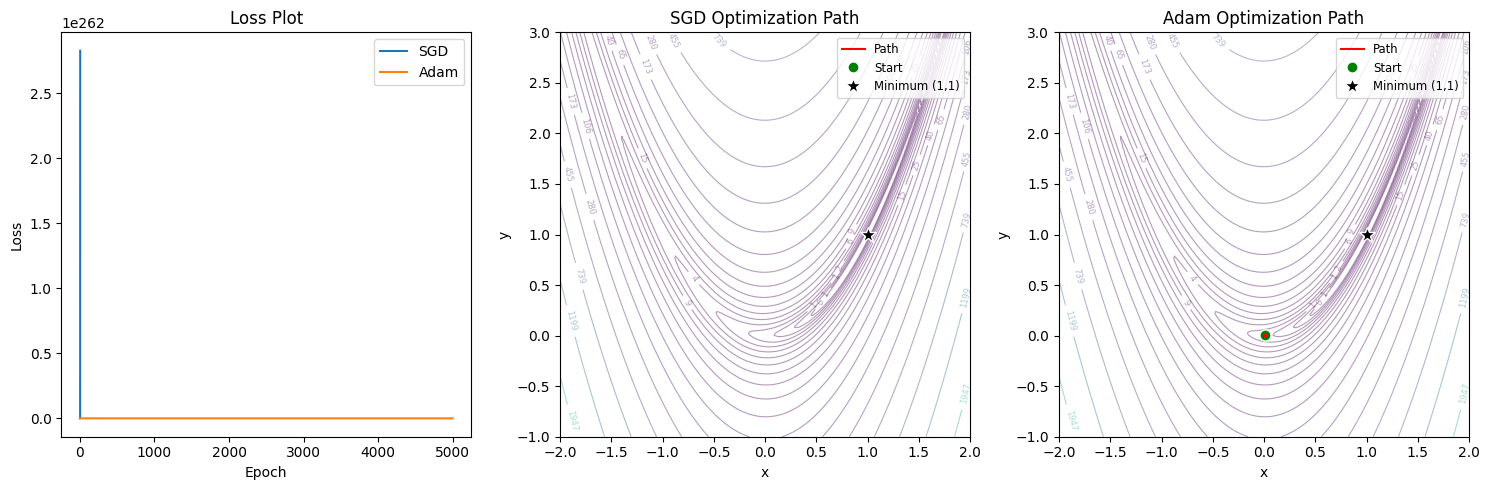

In [103]:
main(lr=1e-1)

/tmp/ipykernel_8646/4060118950.py:1: RuntimeWarning: overflow encountered in scalar power
  f = lambda x: x[0]**2 + 100 * (x[1] - x[0]**2)**2    # rosenbrock function
/tmp/ipykernel_8646/4060118950.py:2: RuntimeWarning: overflow encountered in scalar power
  fgrad = lambda x: np.array([2*x[0] + 400 * x[0]**3 - 400*x[0]*x[1], 200*x[1] - 200 * x[0]**2])    # (df/dx, df/dy)
/tmp/ipykernel_8646/4060118950.py:1: RuntimeWarning: invalid value encountered in scalar subtract
  f = lambda x: x[0]**2 + 100 * (x[1] - x[0]**2)**2    # rosenbrock function
/tmp/ipykernel_8646/4060118950.py:2: RuntimeWarning: invalid value encountered in scalar subtract
  fgrad = lambda x: np.array([2*x[0] + 400 * x[0]**3 - 400*x[0]*x[1], 200*x[1] - 200 * x[0]**2])    # (df/dx, df/dy)


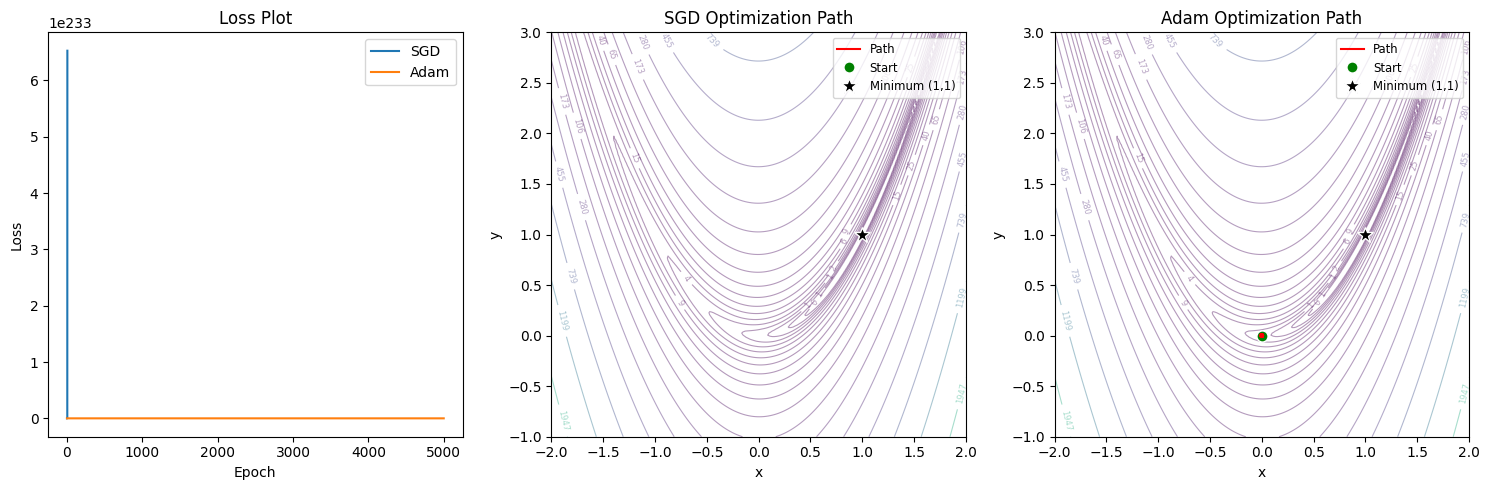

In [89]:
main(lr=1e-2)

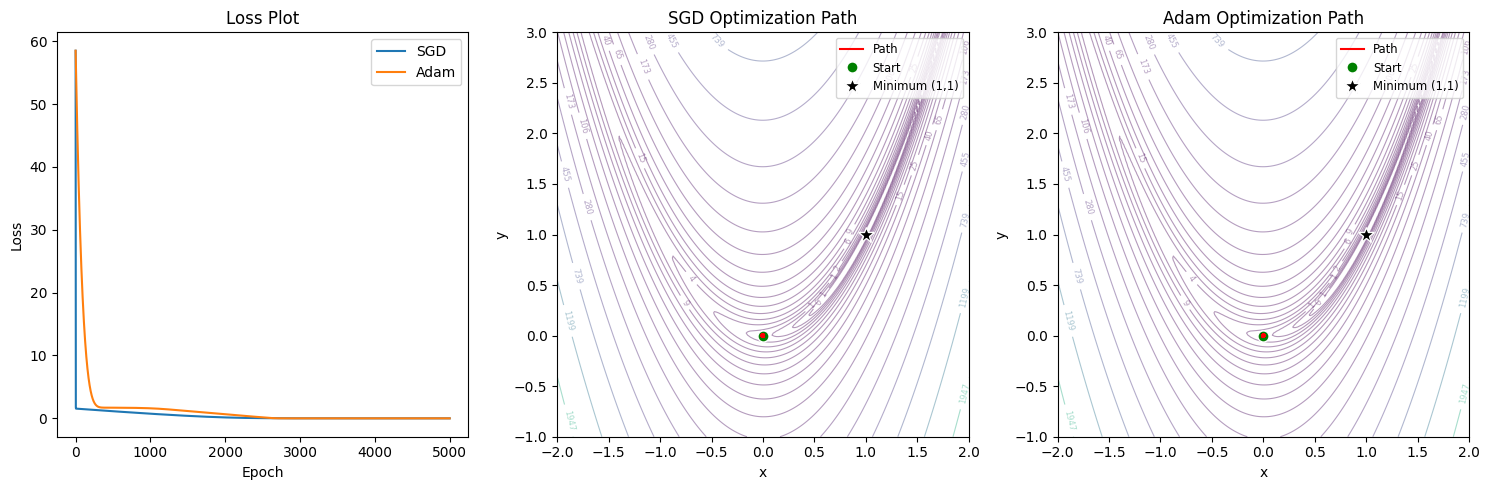

In [90]:
main(lr=1e-3)

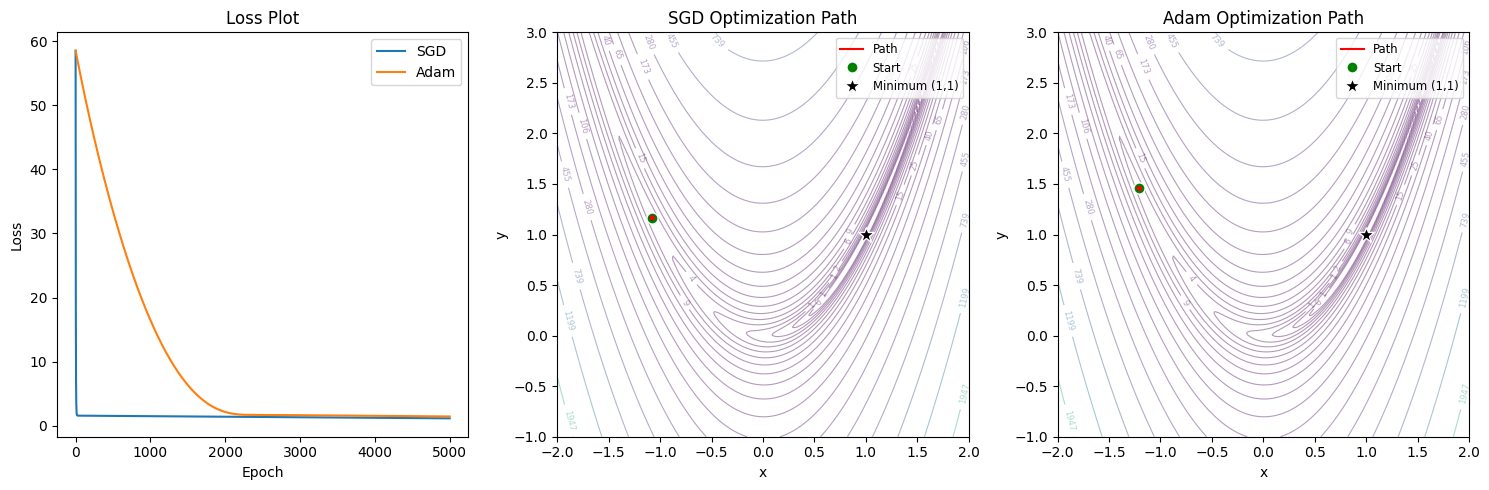

In [91]:
main(lr=1e-4)

* SGD converged more quickly than Adam for lr $10^{-3}$.
* Adam updates are more stable, whereas SGD took a huge step followed by very small steps for lr $10^{-3}$.
* SGD is very sensitive to learning rate -- for lr $10^{-1}, 10^{-2}$, its initial step itself was so huge that it never converged to minimum point. But Adam optimizer still converged even with these big learning rates.

## Solution 6

RMS: Final parameters: [3.8374129  0.12856729], Final Loss: 13.263623403357844
Adam: Final parameters: [ 3.83746677e+00 -3.81600703e-06], Final Loss: 4.1577927955732354


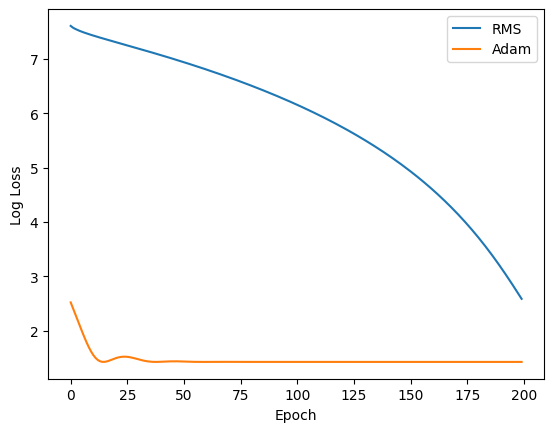

In [10]:
f = lambda w: 0.5 * (w[0]**2 + 1000 * w[1]**2) + 5 * np.sin(w[0])    # objective
fgrad = lambda w: np.array([w[0] + 5 * np.cos(w[0]), 1000 * w[1]])   
w = np.array([2.0, 2.0])    # initial values
epsilon = 1e-6
max_epochs = 200
lr = 0.01

class RMSProp:
    def __init__(self) -> None:
        self.v = 0
        self.beta = 0.9

    def weight_difference(self, gradient, _epoch: int):
        self.v = self.beta * self.v + (1 - self.beta) * gradient**2
        return lr * gradient / (np.sqrt(self.v) + epsilon)

class Adam:
    def __init__(self) -> None:
        self.m = 0
        self.v = 0
        self.beta_1 = 0.9
        self.beta_2 = 0.99

    def weight_difference(self, gradient, epoch: int):
        # first moment
        self.m = self.beta_1 * self.m + (1 - self.beta_1) * gradient
        k = self.m / (1 - self.beta_1 ** epoch)
        # second moment
        self.v = self.beta_2 * self.v + (1 - self.beta_2) * gradient**2
        s = self.v / (1 - self.beta_2 ** epoch)
        return lr * k / (np.sqrt(s) + epsilon)

def fit(w: np.ndarray, optimizer) -> tuple[np.ndarray, list[float]]:
    losses = []
    for epoch in range(1, max_epochs+1):
        losses.append(f(w))
        gradient = fgrad(w)
        w -= optimizer.weight_difference(gradient, epoch)
    return w, losses

rms_w, rms_losses = fit(w, RMSProp())
print(f'RMS: Final parameters: {rms_w}, Final Loss: {rms_losses[-1]}')
adam_w, adam_losses = fit(w, Adam())
print(f'Adam: Final parameters: {adam_w}, Final Loss: {adam_losses[-1]}')

plt.plot(np.log(rms_losses), label='RMS')
plt.plot(np.log(adam_losses), label='Adam')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.legend()
plt.show()

## Solution 8

In [45]:
minus_plus = lambda x: (-x, x)
rng = np.random.default_rng(seed=42)

initializations = {
    'zero': lambda in_size, out_size: np.zeros(shape=(out_size, in_size)),
    'normal': lambda in_size, out_size: rng.standard_normal(size=(out_size, in_size)),
    'xavier': lambda in_size, out_size: rng.uniform(*minus_plus(np.sqrt(6 / (in_size + out_size))), size=(out_size, in_size)),
    'kaimeng': lambda in_size, out_size: rng.normal(0, 2 / in_size, size=(out_size, in_size)),
}
activations = {
    'relu': lambda z: np.where(z > 0, z, 0),
    'sigmoid': lambda z: 1 / (1 + np.exp(-z)),
}

batch_size = 128
input_size = 3
hidden_size = 5
output_size = 5     
x = rng.normal(size=(batch_size, input_size))

def plot_activations(initialization_name: str, activation_name: str) -> None:
    weight_init = initializations[initialization_name]
    W1 = weight_init(input_size, hidden_size)
    W2 = weight_init(hidden_size, output_size)
    hidden = activations[activation_name](x @ W1.T)
    y = hidden @ W2.T

    fig, axes = plt.subplots(1,2,figsize=(8,5))
    for i, layer in enumerate((hidden, y)):
        axes[i].bar(np.arange(1,6), height=np.var(layer, axis=0))
        axes[i].set_title(f'Layer {i+1}')
        axes[i].set_xlabel('Neuron')
        axes[i].set_ylabel('Activation Variance')
    fig.tight_layout(w_pad=1.5)

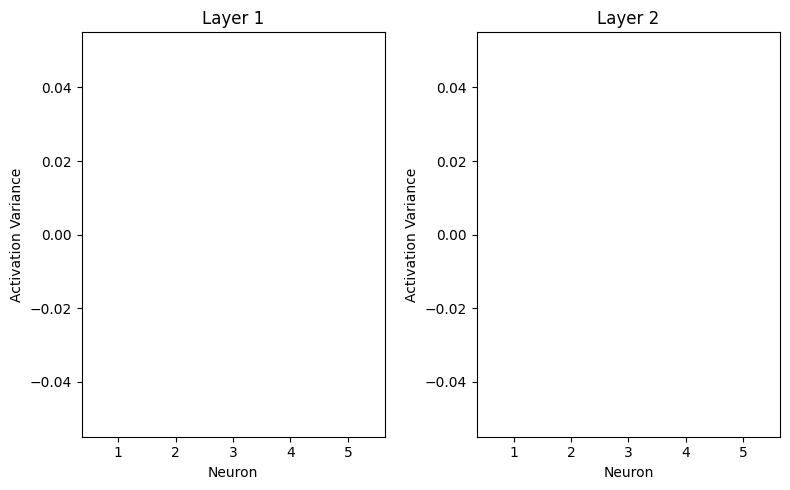

In [ ]:
plot_activations('zero', 'relu')        # both layers' bar plots look "empty" as all neurons' variances are 0, so no bar is drawns

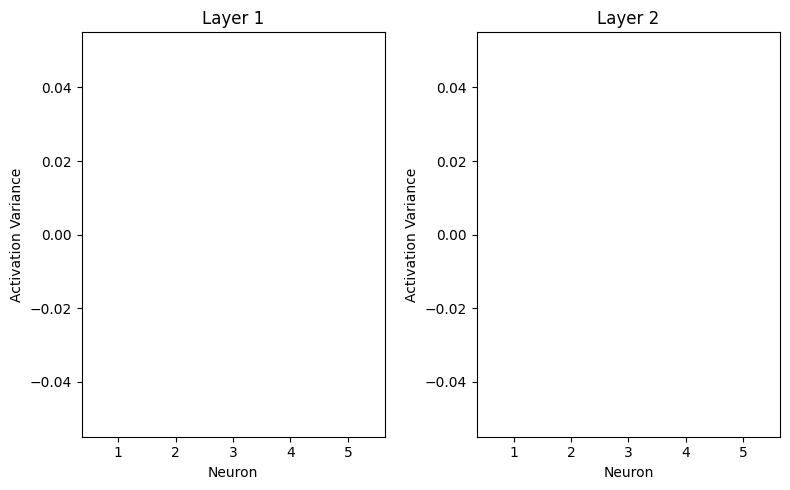

In [ ]:
plot_activations('zero', 'sigmoid')      # both layers' bar plots look "empty" as all neurons' variances are 0, so no bar is drawns

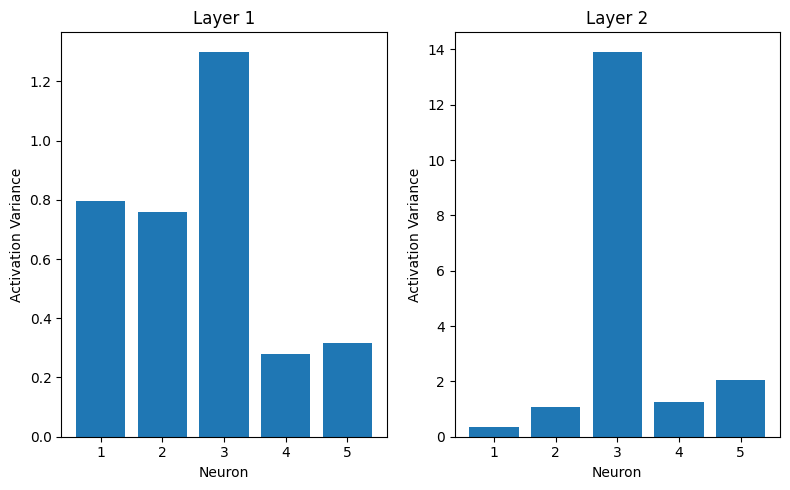

In [48]:
plot_activations('normal', 'relu')

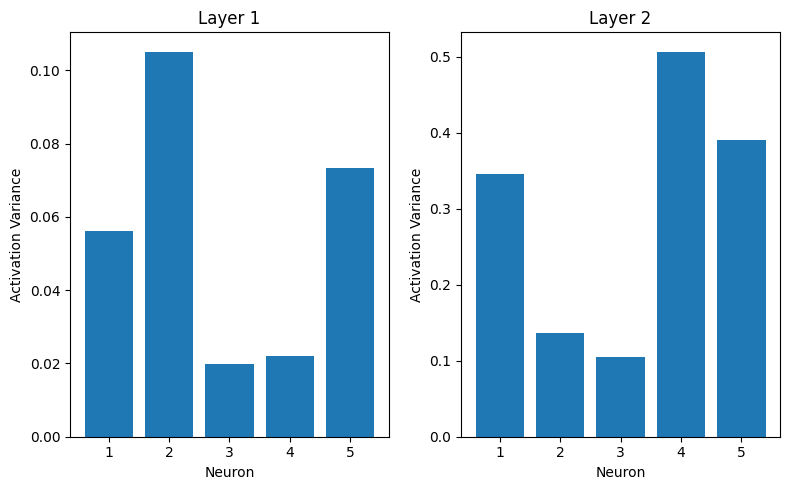

In [50]:
plot_activations('normal', 'sigmoid')

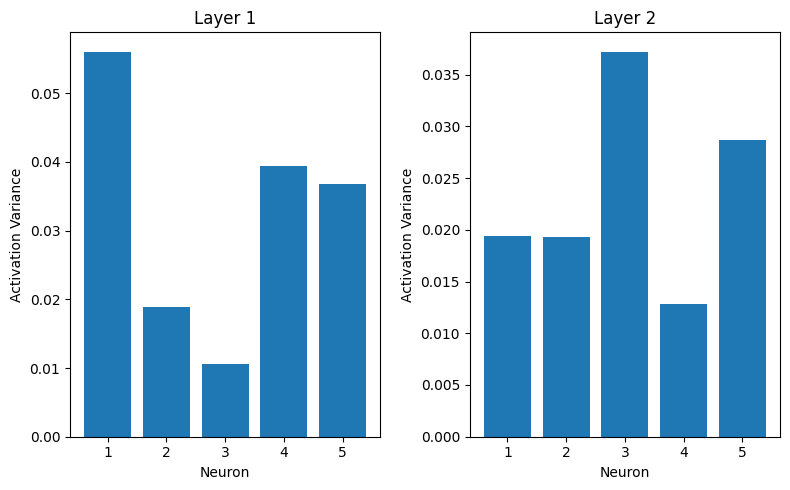

In [51]:
plot_activations('xavier', 'sigmoid')

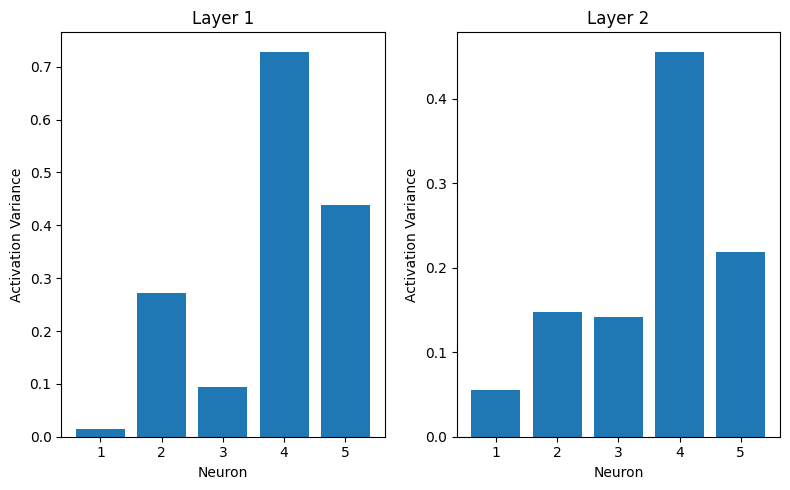

In [52]:
plot_activations('kaimeng', 'relu')

## Solution 10

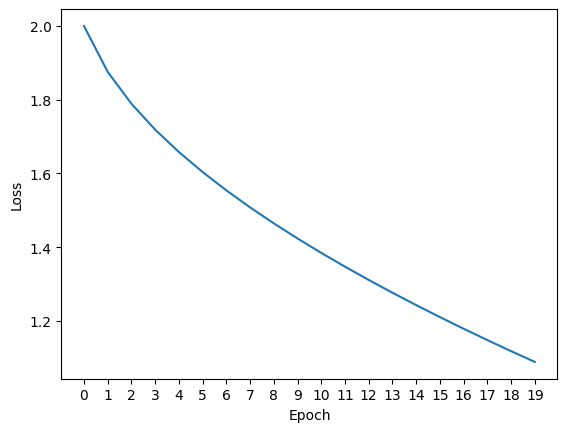

In [57]:
w = 1.5
x = 2
y = 1
lr = 0.01
epochs = 20
# RMS Prop
beta = 0.9   
v = 0
epsilon = 1e-6

losses = []
for _ in range(epochs):
    ypred = max(0, w * x)   # ReLU
    losses.append(0.5 * (ypred - y)**2)
    grad = (ypred - y) * (ypred > 0) * x    # gradient calculated by chain rule

    v = beta * v + (1 - beta) * grad**2
    w -= lr * grad / (math.sqrt(v) + epsilon)      # weight update

plt.plot(losses)
plt.xticks(range(20))
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## Solution 12

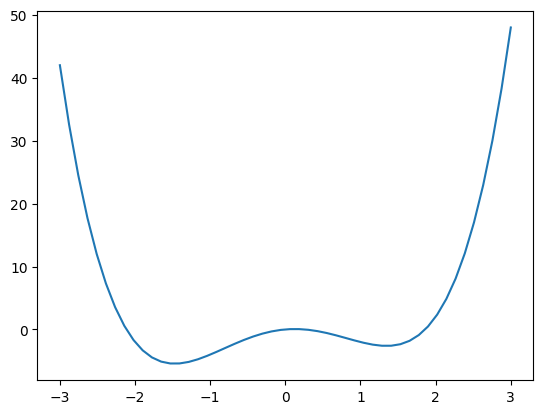

In [5]:
L = lambda x: x**4 - 4 * x**2 + x
Lgrad = lambda x: 4 * x**3 - 8 * x + 1
x = np.linspace(-3, 3)
y = L(x)
plt.plot(x, y)
plt.show()

Above plot shows L(x) has 2 local minima and 1 local maxima.

Standard Gradient Descent (starting from -1.5) converged to x = -1.4729976011140307
Standard Gradient Descent (starting from 1.5) converged to x = 1.3469974085277747
Adam optimizer (starting from -1.5) converged to x = -1.472997604574784
Adam optimizer (starting from 1.5) converged to x = 1.3469973971406244


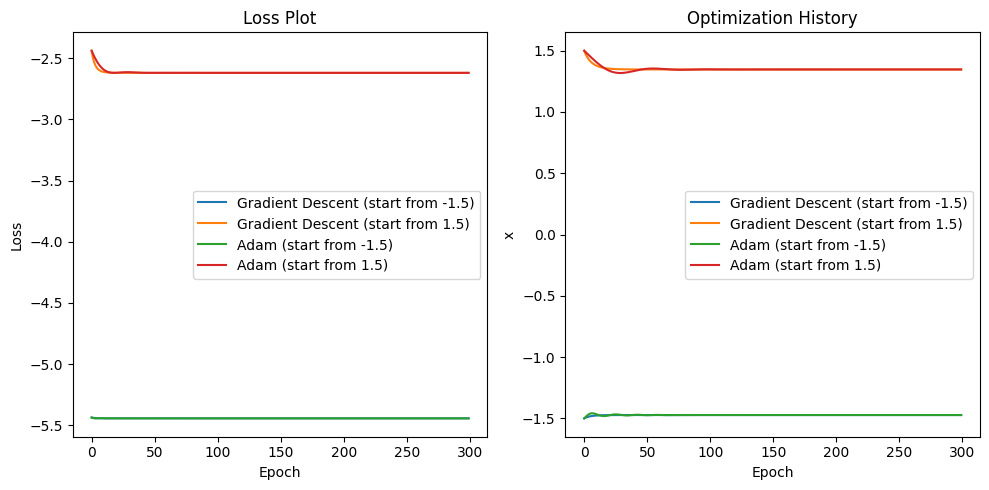

In [19]:
max_epochs = 300
lr = 0.01
epsilon = 1e-6     # for numerical stability in Adam optimizer

def gradient_descent(gradient, _epoch):
    return lr * gradient

class Adam:
    def __init__(self) -> None:
        self.m = 0
        self.v = 0
        self.beta_1 = 0.9
        self.beta_2 = 0.99

    def __call__(self, gradient, epoch: int):
        # first moment
        self.m = self.beta_1 * self.m + (1 - self.beta_1) * gradient
        k = self.m / (1 - self.beta_1 ** epoch)
        # second moment
        self.v = self.beta_2 * self.v + (1 - self.beta_2) * gradient**2
        s = self.v / (1 - self.beta_2 ** epoch)
        return lr * k / (np.sqrt(s) + epsilon)

def fit(x: float, optimizer) -> tuple[list[float], list[float]]:
    losses = []
    xhistory = []
    for epoch in range(1, max_epochs+1):
        xhistory.append(x)
        losses.append(L(x))
        gradient = Lgrad(x)
        x -= optimizer(gradient, epoch)
    return xhistory, losses

xs_grad_1, losses_grad_1 = fit(-1.5, gradient_descent)
print('Standard Gradient Descent (starting from -1.5) converged to x =', xs_grad_1[-1])

xs_grad_2, losses_grad_2 = fit(1.5, gradient_descent)
print('Standard Gradient Descent (starting from 1.5) converged to x =', xs_grad_2[-1])

xs_adam_1, losses_adam_1 = fit(-1.5, Adam())
print('Adam optimizer (starting from -1.5) converged to x =', xs_adam_1[-1])

xs_adam_2, losses_adam_2 = fit(1.5, Adam())
print('Adam optimizer (starting from 1.5) converged to x =', xs_adam_2[-1])

fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].plot(losses_grad_1, label='Gradient Descent (start from -1.5)')
axes[0].plot(losses_grad_2, label='Gradient Descent (start from 1.5)')
axes[0].plot(losses_adam_1, label='Adam (start from -1.5)')
axes[0].plot(losses_adam_2, label='Adam (start from 1.5)')
axes[0].set_title('Loss Plot')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(xs_grad_1, label='Gradient Descent (start from -1.5)')
axes[1].plot(xs_grad_2, label='Gradient Descent (start from 1.5)')
axes[1].plot(xs_adam_1, label='Adam (start from -1.5)')
axes[1].plot(xs_adam_2, label='Adam (start from 1.5)')
axes[1].set_title('Optimization History')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('x')
axes[1].legend()
fig.tight_layout()

* Different initializations (-1.5 and 1.5) lead to different values as optimizer converges to different local minima (depending on which side of the local maxima does initial value lie).
* Above code is deterministic. But in general randomness is involved in picking initial starting points, and gradient calculation in neural network based on outputs of a random mini-batch. So it's important to fix a seed for randomness to ensure reproducibility.
* In non-convex loss functions, multiple minima can be present. So trying different random seeds makes it likely that we will converge to different minima each time, and then we can choose best result from all of them.

## Solution 14

In [49]:
f = lambda w: 5 * w[0]**2 + 0.5 * w[1] ** 2
fgrad = lambda w: np.array([10 * w[0], w[1]])
lr = 0.1
beta = 0.9       # for Momentum
max_epochs = 100

sgd = lambda gradient: lr * gradient

class Momentum:
    def __init__(self) -> None:
        self.v = 0

    def __call__(self, gradient):
        self.v = beta * self.v + gradient
        return lr * self.v
    
def fit(w, optimizer):
    history = np.zeros(shape=(max_epochs, 2))
    losses = []
    for epoch in range(max_epochs):
        history[epoch, :] = w
        losses.append(f(w))
        w -= optimizer(fgrad(w))
    return history, losses

history_sgd, losses_sgd = fit(np.array([2.0, 2.0]), sgd)
print('SGD Final Parameter values:', history_sgd[-1])
print('SGD Final Loss:', losses_sgd[-1])
history_momentum, losses_momentum = fit(np.array([2.0, 2.0]), Momentum())
print('Momentum Final Parameter values:', history_momentum[-1])
print('Momentum Final Loss:', losses_momentum[-1])


SGD Final Parameter values: [0.00000000e+00 5.90253309e-05]
SGD Final Loss: 1.7419948416432898e-09
Momentum Final Parameter values: [0.01192231 0.00984233]
Momentum Final Loss: 0.0007591429084991348


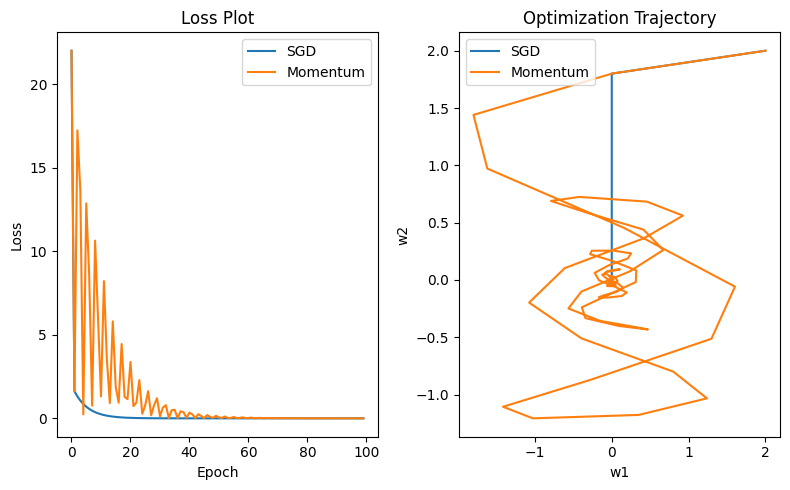

In [51]:
fig, axes = plt.subplots(1,2, figsize=(8,5))

axes[0].plot(losses_sgd, label='SGD')
axes[0].plot(losses_momentum, label='Momentum')
axes[0].set_title('Loss Plot')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_sgd[:, 0], history_sgd[:, 1], label='SGD')
axes[1].plot(history_momentum[:, 0], history_momentum[:, 1], label='Momentum')
axes[1].set_title('Optimization Trajectory')
axes[1].set_xlabel('w1')
axes[1].set_ylabel('w2')
axes[1].legend()

fig.tight_layout()

Hessian Matrix is:
$$\nabla^2 f(w) = \begin{bmatrix} 10 & 0 \\ 0 & 1 \end{bmatrix}$$

Eigenvalues of Hessian are $10, 1$ - $w_2$ direction is "shallow" as its eigen-value is much less.

In SGD, it moves slowly in shallow direction $w_2$ as its gradients are small. 
But in momentum, it retains previous momentum even when gradients are small, leading it to oscillate but converge quicker in $w_2$ direction.

## Solution 15

$$
f(w_1, w_2) = 3 w_1^2 + 2 w_1 w_2 + 2 w_2^2 \quad (\text{Loss}) \\
\nabla f = \begin{bmatrix} 6 w_1 + 2 w_2 \\ 2 w_1 + 4 w_2 \end{bmatrix} \quad (\text{Gradient}) \\
\nabla^2 f = \begin{bmatrix} 6 & 2 \\ 2 & 4 \end{bmatrix} \quad (\text{Hessian})
$$

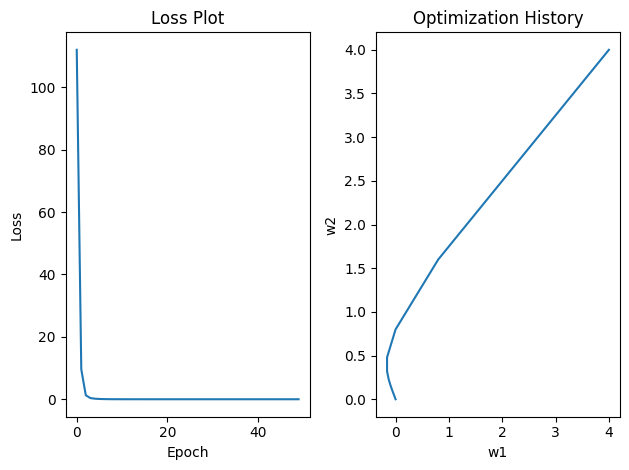

In [57]:
# Gradient Descent

# starting point
w1 = torch.tensor([4.0], requires_grad=True)
w2 = torch.tensor([4.0], requires_grad=True)

optimizer = torch.optim.SGD([w1,w2], lr=0.1)
w1_history, w2_history, losses = [], [], []
for epoch in range(50):
    optimizer.zero_grad()    # clear previous gradients
    f = 3 * w1**2 + 2 * w1 * w2 + 2 * w2**2
    w1_history.append(w1.item())
    w2_history.append(w2.item())
    losses.append(f.item())
    f.backward()        # gradient descent
    optimizer.step()    # update weights

fig, axes = plt.subplots(1, 2)
axes[0].plot(losses)
axes[0].set_title('Loss Plot')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(w1_history, w2_history)
axes[1].set_title('Optimization History')
axes[1].set_xlabel('w1')
axes[1].set_ylabel('w2')
fig.tight_layout()

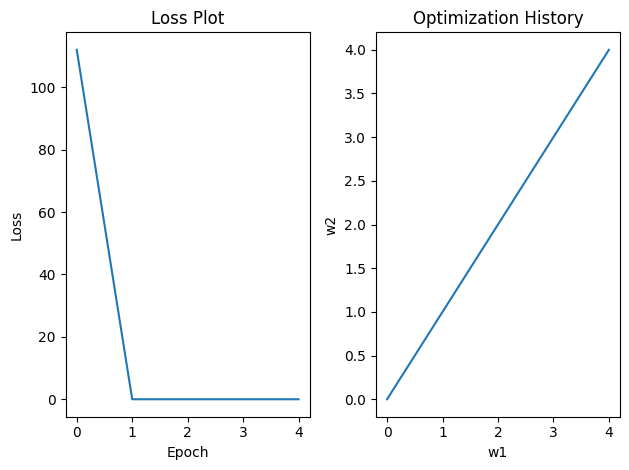

In [63]:
f = lambda w: 3 * w[0]**2 + 2 * w[0] * w[1] + 2 * w[1]**2
hessian = np.array([[6,2], [2,4]])
hessian_inverse = np.linalg.inv(hessian)
gradient = lambda w: hessian @ w
w = np.array([4.0, 4.0])   # starting point
losses = []
w1_history = []
w2_history = []
for epoch in range(5):
    w1_history.append(w[0])
    w2_history.append(w[1])
    losses.append(f(w))
    w -= hessian_inverse @ gradient(w)

fig, axes = plt.subplots(1, 2)
axes[0].plot(losses)
axes[0].set_title('Loss Plot')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(w1_history, w2_history)
axes[1].set_title('Optimization History')
axes[1].set_xlabel('w1')
axes[1].set_ylabel('w2')
fig.tight_layout()


As loss function is quadratic, its Hessian matrix is constant. 
So Newton Update method immediately converges to optimal point $w = (0,0)$, whereas gradient descent takes slightly longer to converge.